In [145]:
import sqlite3
import pandas as pd
import numpy as np
import mne
from mne.preprocessing import ICA
from io import BytesIO
import matplotlib.pyplot as plt

In [146]:
db_path = "/Users/sarah-rosemay/Documents/EEG_data/Combo test/subj-1_ses-S001_task-breathing_ppg_sarah_test_run-001_20010128_225732_eeg.db"

conn = sqlite3.connect(db_path)

table_name = "data_87d03f26-0f33-4e1d-a259-2181ccc29071"

df = pd.read_sql_query(
    f"SELECT * FROM '{table_name}'",
    conn
)

print(df.shape)

(3772, 3)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 8251 samples (33.004 s)



/var/folders/33/qg_ry0_n2kb_gsw589xg9z_w0000gn/T/ipykernel_22837/3733942631.py:1: RuntimeWarning: Estimated head radius (11.2 cm) is above the 99th percentile for adult head size. Check if the montage_units argument is correct (the default is "mm", but your channel positions may be in different units).
  raw = mne.io.read_raw_eeglab(set_path, preload=True)
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s finished


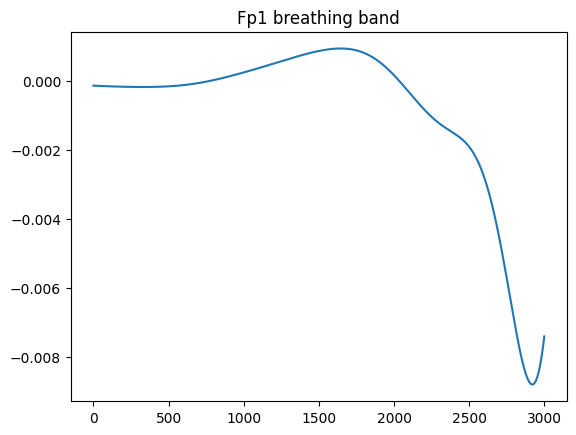

In [147]:

raw = mne.io.read_raw_eeglab(set_path, preload=True)
raw.pick(["Fp1", "Fp2"])

raw.filter(0.1, 40)

eeg_data = raw.get_data()
def bandpass(data, low=0.1, high=0.4, fs=250):

    b, a = butter(2, [low/(fs/2), high/(fs/2)], btype="band")

    return filtfilt(b, a, data)

signal = eeg_data[0]   # Fp1

breath_signal = bandpass(signal)

plt.plot(breath_signal[:3000])

plt.title("Fp1 breathing band")

plt.show()

In [148]:
info = mne.create_info(
    ch_names=["Fp1", "Fp2"],
    sfreq=250,
    ch_types=["eeg", "eeg"]
)

raw = mne.io.RawArray(eeg_data, info)

raw.filter(0.1, 40)

Creating RawArray with float64 data, n_channels=2, n_times=66975
    Range : 0 ... 66974 =      0.000 ...   267.896 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 8251 samples (33.004 s)



[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s finished


Measurement date,Unknown
Experimenter,Unknown
Participant,Unknown
Digitized points,Not available
Good channels,2 EEG
Bad channels,None
EOG channels,Not available
ECG channels,Not available
Sampling frequency,250.00 Hz
Highpass,0.10 Hz
Lowpass,40.00 Hz


In [149]:
ica = ICA(n_components=2, random_state=97, max_iter="auto")
ica.fit(raw)

Fitting ICA to data using 2 channels (please be patient, this may take a while)
Selecting by number: 2 components
Fitting ICA took 0.0s.


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,1 iterations on raw data (66975 samples)
ICA components,2
Available PCA components,2
Channel types,eeg
ICA components marked for exclusion,—


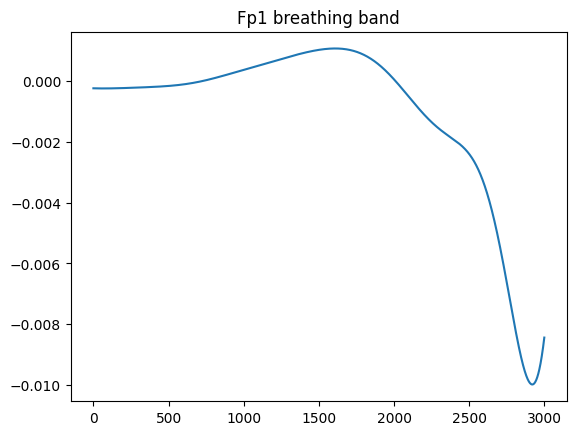

In [150]:
def bandpass(data, low=0.1, high=0.4, fs=250):
    b, a = butter(2, [low/(fs/2), high/(fs/2)], btype="band")
    return filtfilt(b, a, data)

signal = eeg_data[1]   # Fp2

breath_signal = bandpass(signal)

plt.plot(breath_signal[:3000])
plt.title("Fp1 breathing band")
plt.show()

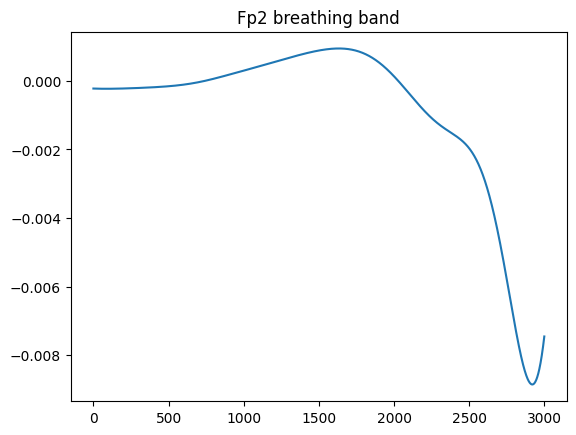

In [151]:
def bandpass(data, low=0.1, high=0.4, fs=250):
    b, a = butter(2, [low/(fs/2), high/(fs/2)], btype="band")
    return filtfilt(b, a, data)

signal = eeg_data[0]   # 0 = Fp1, 1 = Fp2

breath_signal = bandpass(signal)

plt.plot(breath_signal[:3000])
plt.title("Fp2 breathing band")
plt.show()

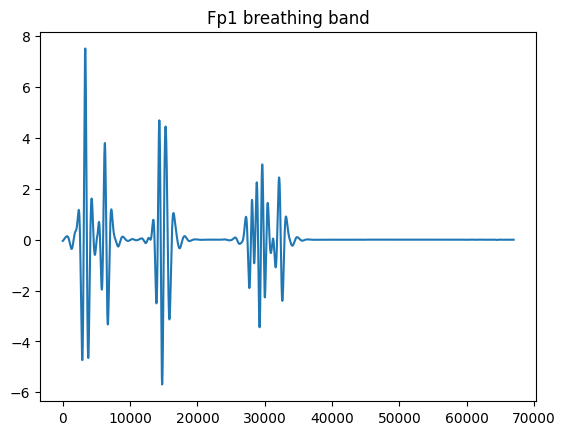

In [152]:
def bandpass(data, low=0.15, high=0.35, fs=250):
    b, a = butter(2, [low/(fs/2), high/(fs/2)], btype="band")
    return filtfilt(b, a, data)

signal = eeg_data[0]   # 0 = Fp1, 1 = Fp2

breath_signal = bandpass(signal)

breath_z = (breath_signal - np.mean(breath_signal)) / np.std(breath_signal)

plt.plot(breath_z)
plt.title("Fp1 breathing band")
plt.show()

In [153]:
from mne.preprocessing import ICA

raw_ica = raw.copy()

ica = ICA(n_components=2, random_state=97, max_iter="auto")
ica.fit(raw_ica)

sources_raw = ica.get_sources(raw_ica)
sources = sources_raw.get_data()

print("sources shape:", sources.shape)

Fitting ICA to data using 2 channels (please be patient, this may take a while)
Selecting by number: 2 components
Fitting ICA took 0.0s.
sources shape: (2, 66975)


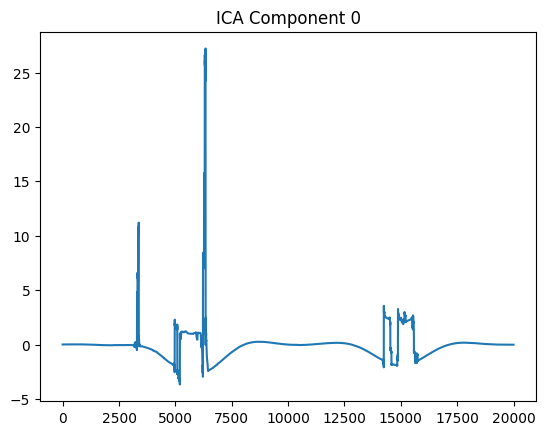

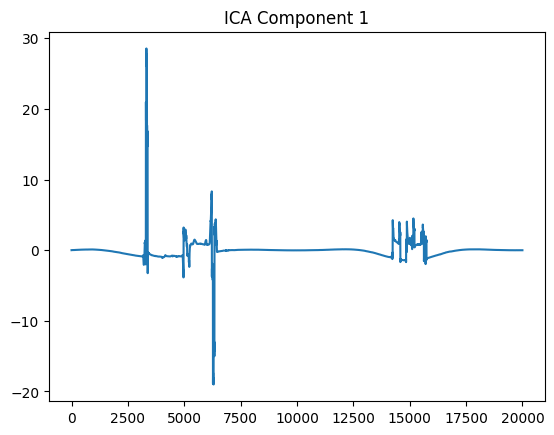

In [154]:
plt.plot(sources[0][:20000])
plt.title("ICA Component 0")
plt.show()

plt.plot(sources[1][:20000])
plt.title("ICA Component 1")
plt.show()

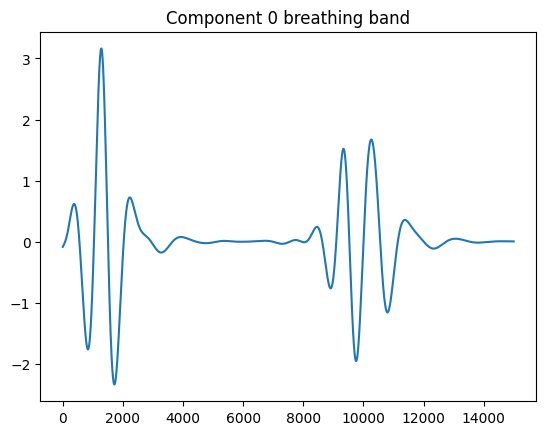

In [155]:
best_comp = 0   # try 0, then try 1

breath_signal = bandpass(sources[best_comp])

plt.plot(breath_signal[5000:20000])
plt.title(f"Component {best_comp} breathing band")
plt.show()

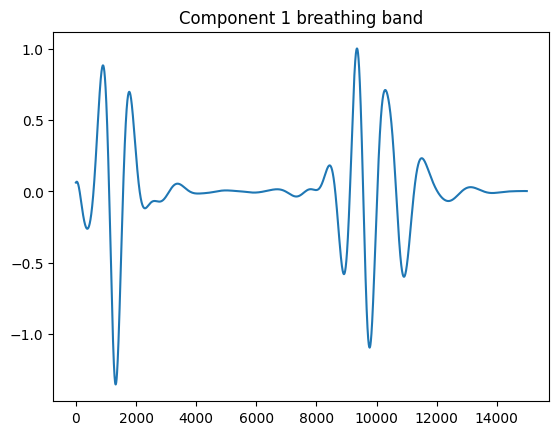

In [156]:
best_comp = 1

breath_signal = bandpass(sources[best_comp])

plt.plot(breath_signal[5000:20000])
plt.title(f"Component {best_comp} breathing band")
plt.show()

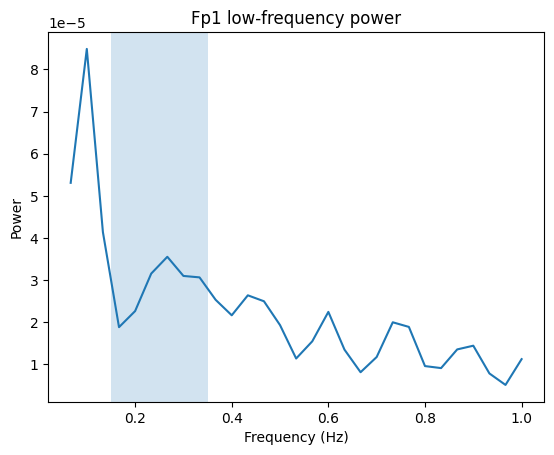

Fp1 peak in breathing band: 0.26666666666666666 Hz


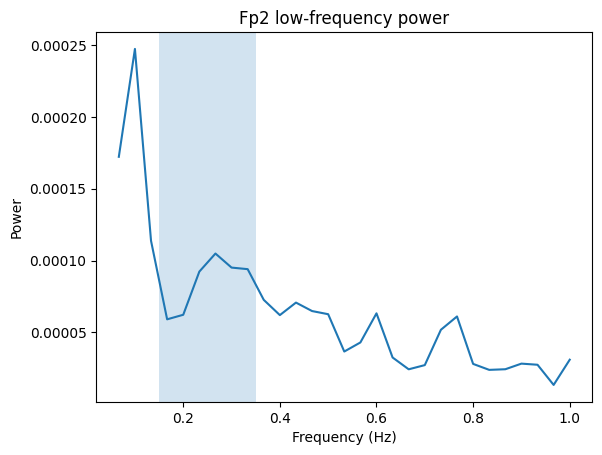

Fp2 peak in breathing band: 0.26666666666666666 Hz


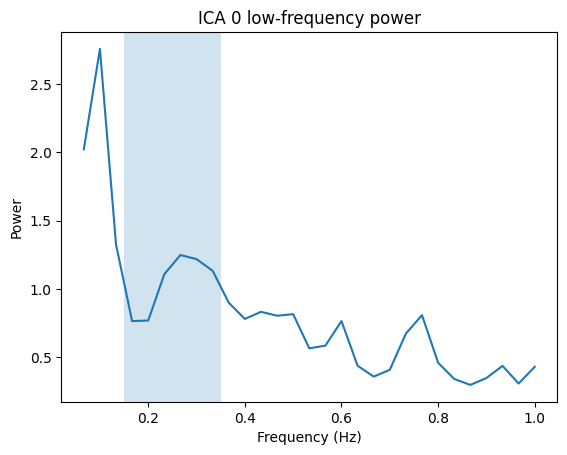

ICA 0 peak in breathing band: 0.26666666666666666 Hz


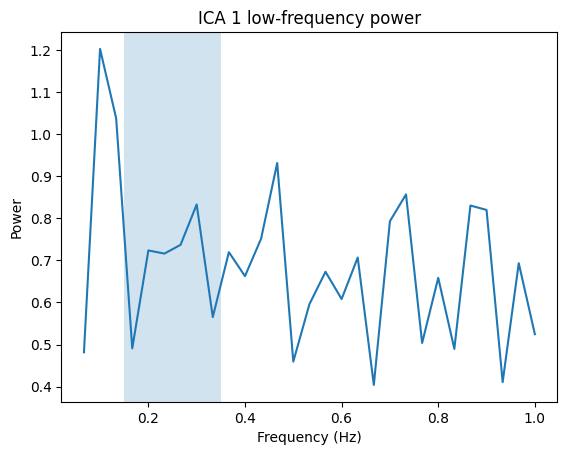

ICA 1 peak in breathing band: 0.3 Hz


In [157]:
from scipy.signal import welch
import matplotlib.pyplot as plt
import numpy as np

fs = 250

signals = {
    "Fp1": eeg_data[0],
    "Fp2": eeg_data[1],
    "ICA 0": sources[0],
    "ICA 1": sources[1],
}

for name, sig in signals.items():
    f, pxx = welch(sig, fs=fs, nperseg=fs*30)

    mask = (f >= 0.05) & (f <= 1.0)

    plt.figure()
    plt.plot(f[mask], pxx[mask])
    plt.axvspan(0.15, 0.35, alpha=0.2)
    plt.title(f"{name} low-frequency power")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power")
    plt.show()

    breath_mask = (f >= 0.15) & (f <= 0.35)
    peak_freq = f[breath_mask][np.argmax(pxx[breath_mask])]

    print(name, "peak in breathing band:", peak_freq, "Hz")

In [158]:
raw_clean = raw.copy()

# remove very large spikes
raw_clean = raw_clean.copy().crop(tmin=5)

# stronger high-pass to reduce drift
raw_clean.filter(0.05, 5)

eeg_clean = raw_clean.get_data()

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.05 - 5 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.05
- Lower transition bandwidth: 0.05 Hz (-6 dB cutoff frequency: 0.03 Hz)
- Upper passband edge: 5.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 6.00 Hz)
- Filter length: 16501 samples (66.004 s)



[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s finished


In [159]:
signal = eeg_clean[0]

In [171]:
# Wider respiration band first
breath_signal = bandpass(signal, low=0.08, high=0.5)

# Remove mean / normalize
breath_z = (breath_signal - np.mean(breath_signal)) / np.std(breath_signal)

# Stricter peak detection
peaks, props = find_peaks(
    breath_z,
    distance=int(fs * 2.5),          # at least 2.5 sec between breaths
    prominence=0.75                 # stronger peaks only
)

duration_sec = len(breath_z) / fs
breaths_per_min = len(peaks) / duration_sec * 60

print("Estimated respiration rate:", breaths_per_min, "breaths/min")
print("Number of detected peaks:", len(peaks))print("Estimated respiration rate:", breaths_per_min, "breaths/min")

SyntaxError: invalid syntax (668257388.py, line 18)

In [170]:
print("Signal shape:", signal.shape)
print("Signal min:", np.min(signal))
print("Signal max:", np.max(signal))
print("Signal std:", np.std(signal))
print("Number zeros:", np.sum(signal == 0))
print("Percent zeros:", np.mean(signal == 0) * 100)

Signal shape: (65725,)
Signal min: -0.021193531479845915
Signal max: 0.11492633539920236
Signal std: 0.005003224269492779
Number zeros: 0
Percent zeros: 0.0


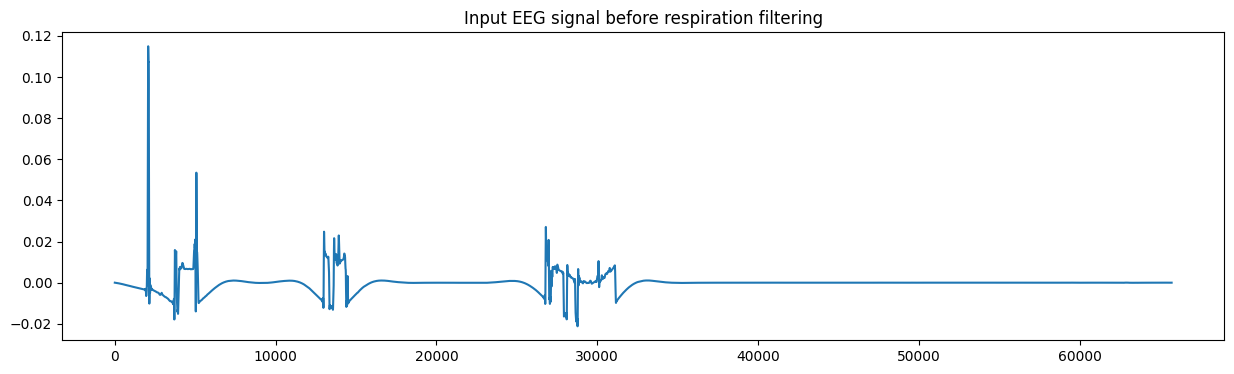

In [168]:
plt.figure(figsize=(15,4))
plt.plot(signal)
plt.title("Input EEG signal before respiration filtering")
plt.show()

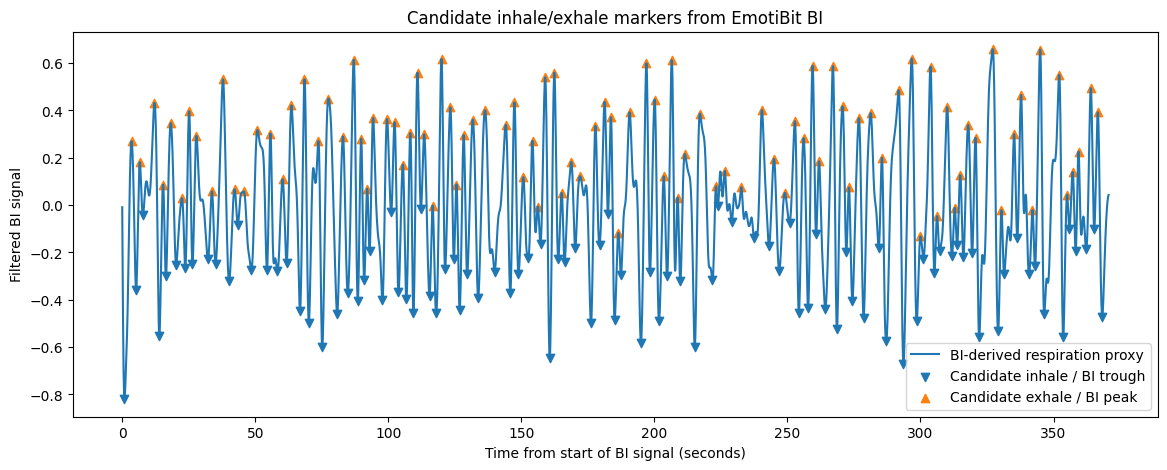

Number of candidate inhales: 96
Number of candidate exhales: 97


In [172]:
from scipy.interpolate import interp1d
from scipy.signal import butter, filtfilt, find_peaks
import numpy as np
import matplotlib.pyplot as plt

# ---- 1. Get BI values ----
bi_vals = bi[6].astype(float).values

# If BI is in milliseconds, convert to seconds
# Typical BI values might be 600–1200 ms
if np.nanmedian(bi_vals) > 10:
    bi_sec = bi_vals / 1000
else:
    bi_sec = bi_vals.copy()

# ---- 2. Remove extreme/outlier BI values ----
good = (bi_sec > 0.3) & (bi_sec < 2.0)  # 30–200 bpm approx
bi_sec_clean = bi_sec[good]

# ---- 3. Create approximate time axis from cumulative BI ----
# This gives beat times in seconds
beat_time = np.cumsum(bi_sec_clean)
beat_time = beat_time - beat_time[0]

# ---- 4. Interpolate BI onto regular time grid ----
fs_resp = 10  # 10 Hz is enough for respiration proxy
t_resp = np.arange(beat_time[0], beat_time[-1], 1/fs_resp)

interp_func = interp1d(
    beat_time,
    bi_sec_clean,
    kind="linear",
    bounds_error=False,
    fill_value="extrapolate"
)

bi_regular = interp_func(t_resp)

# ---- 5. Filter BI in respiration range ----
def bandpass(x, fs, low=0.08, high=0.5, order=2):
    nyq = fs / 2
    b, a = butter(order, [low/nyq, high/nyq], btype="band")
    return filtfilt(b, a, x)

bi_resp = bandpass(bi_regular, fs_resp, low=0.08, high=0.5)

# ---- 6. Find candidate inhale/exhale markers ----
# BI troughs = shorter BI / faster HR = often inhale-related
# BI peaks = longer BI / slower HR = often exhale-related

min_breath_distance_sec = 2.0  # prevents impossible rapid breathing
min_dist = int(min_breath_distance_sec * fs_resp)

exhale_peaks, _ = find_peaks(
    bi_resp,
    distance=min_dist,
    prominence=np.std(bi_resp) * 0.3
)

inhale_troughs, _ = find_peaks(
    -bi_resp,
    distance=min_dist,
    prominence=np.std(bi_resp) * 0.3
)

# ---- 7. Plot result ----
plt.figure(figsize=(14, 5))
plt.plot(t_resp, bi_resp, label="BI-derived respiration proxy")

plt.scatter(
    t_resp[inhale_troughs],
    bi_resp[inhale_troughs],
    label="Candidate inhale / BI trough",
    marker="v"
)

plt.scatter(
    t_resp[exhale_peaks],
    bi_resp[exhale_peaks],
    label="Candidate exhale / BI peak",
    marker="^"
)

plt.xlabel("Time from start of BI signal (seconds)")
plt.ylabel("Filtered BI signal")
plt.title("Candidate inhale/exhale markers from EmotiBit BI")
plt.legend()
plt.show()

print("Number of candidate inhales:", len(inhale_troughs))
print("Number of candidate exhales:", len(exhale_peaks))

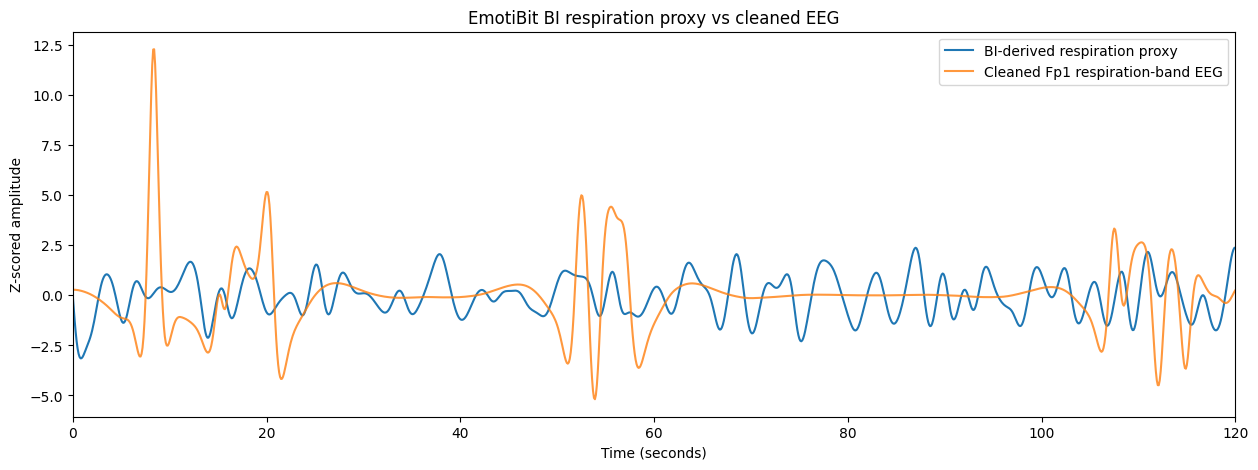

In [175]:
# --------------------------------------------------
# Compare EmotiBit BI breathing to CLEANED EEG
# --------------------------------------------------

fs_eeg = 250

# Use cleaned EEG
eeg_signal = eeg_clean[0]   # Fp1 cleaned
eeg_time = np.arange(len(eeg_signal)) / fs_eeg

# Filter cleaned EEG in respiration band
eeg_resp = bandpass(
    eeg_signal,
    fs=fs_eeg,
    low=0.08,
    high=0.5
)

# Normalize EEG respiration signal
eeg_resp_z = (
    eeg_resp - np.mean(eeg_resp)
) / np.std(eeg_resp)

# Normalize BI respiration signal
bi_resp_z = (
    bi_resp - np.mean(bi_resp)
) / np.std(bi_resp)

# Put EEG onto BI time axis
eeg_on_bi_time = np.interp(
    t_resp,
    eeg_time,
    eeg_resp_z
)

eeg_on_bi_time_z = (
    eeg_on_bi_time - np.mean(eeg_on_bi_time)
) / np.std(eeg_on_bi_time)

# Plot comparison
plt.figure(figsize=(15,5))

plt.plot(
    t_resp,
    bi_resp_z,
    label="BI-derived respiration proxy"
)

plt.plot(
    t_resp,
    eeg_on_bi_time_z,
    label="Cleaned Fp1 respiration-band EEG",
    alpha=0.8
)

plt.xlim(0, min(120, t_resp[-1]))

plt.xlabel("Time (seconds)")
plt.ylabel("Z-scored amplitude")

plt.title("EmotiBit BI respiration proxy vs cleaned EEG")

plt.legend()
plt.show()

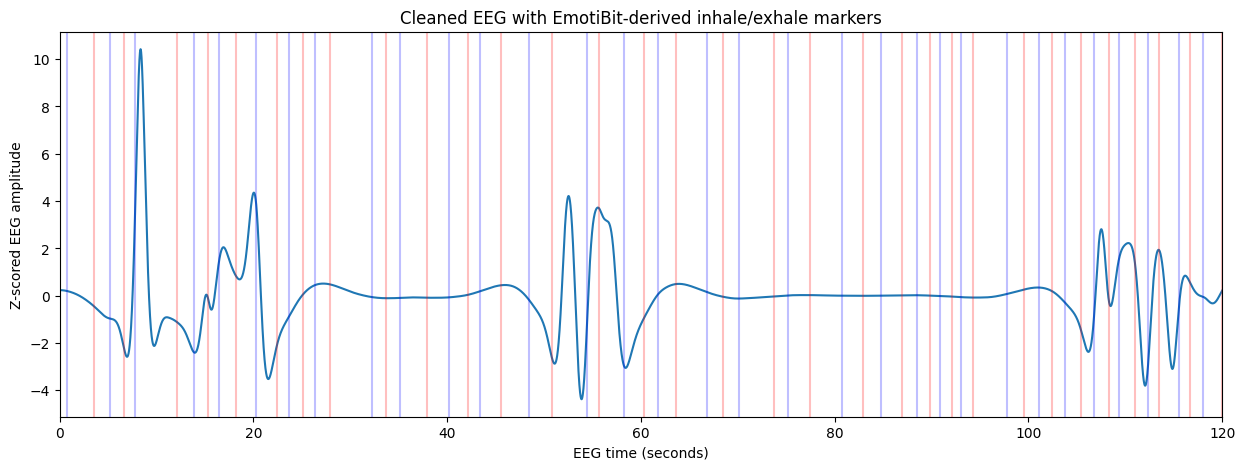

In [176]:
# --------------------------------------------------
# 9. Plot cleaned EEG with BI-derived inhale/exhale markers
# --------------------------------------------------

inhale_times = t_resp[inhale_troughs]
exhale_times = t_resp[exhale_peaks]

plt.figure(figsize=(15, 5))
plt.plot(eeg_time, eeg_resp_z, label="Cleaned Fp1 respiration-band EEG")

for t in inhale_times:
    if 0 <= t <= eeg_time[-1]:
        plt.axvline(t, color="blue", alpha=0.25)

for t in exhale_times:
    if 0 <= t <= eeg_time[-1]:
        plt.axvline(t, color="red", alpha=0.25)

plt.xlim(0, min(120, eeg_time[-1]))
plt.xlabel("EEG time (seconds)")
plt.ylabel("Z-scored EEG amplitude")
plt.title("Cleaned EEG with EmotiBit-derived inhale/exhale markers")
plt.show()

EEG dominant breathing freq: 0.1 Hz
EEG breaths/min: 6.0
BI dominant breathing freq: 0.13333333333333333 Hz
BI breaths/min: 8.0


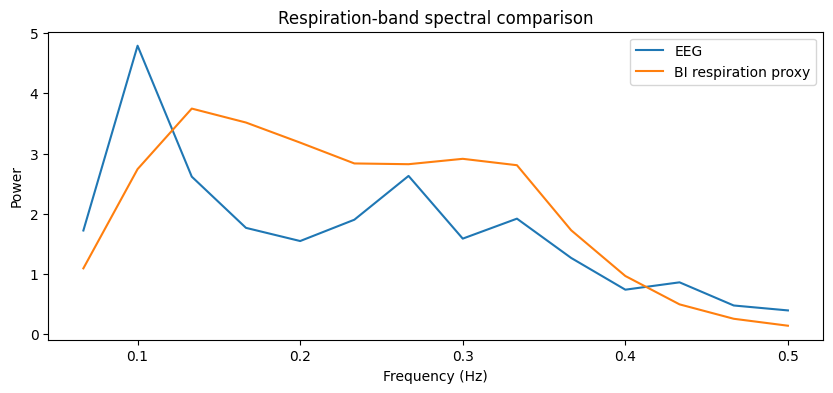

In [177]:
# --------------------------------------------------
# Compare dominant respiration frequencies
# --------------------------------------------------

from scipy.signal import welch

# EEG respiration-band PSD
f_eeg, pxx_eeg = welch(
    eeg_resp_z,
    fs=fs_eeg,
    nperseg=fs_eeg * 30
)

# BI respiration PSD
f_bi, pxx_bi = welch(
    bi_resp_z,
    fs=fs_resp,
    nperseg=min(len(bi_resp_z), fs_resp * 30)
)

# breathing range
mask_eeg = (f_eeg >= 0.05) & (f_eeg <= 0.5)
mask_bi = (f_bi >= 0.05) & (f_bi <= 0.5)

eeg_peak_freq = f_eeg[mask_eeg][np.argmax(pxx_eeg[mask_eeg])]
bi_peak_freq = f_bi[mask_bi][np.argmax(pxx_bi[mask_bi])]

print("EEG dominant breathing freq:", eeg_peak_freq, "Hz")
print("EEG breaths/min:", eeg_peak_freq * 60)

print("BI dominant breathing freq:", bi_peak_freq, "Hz")
print("BI breaths/min:", bi_peak_freq * 60)

plt.figure(figsize=(10,4))

plt.plot(
    f_eeg[mask_eeg],
    pxx_eeg[mask_eeg],
    label="EEG"
)

plt.plot(
    f_bi[mask_bi],
    pxx_bi[mask_bi],
    label="BI respiration proxy"
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Respiration-band spectral comparison")

plt.legend()
plt.show()

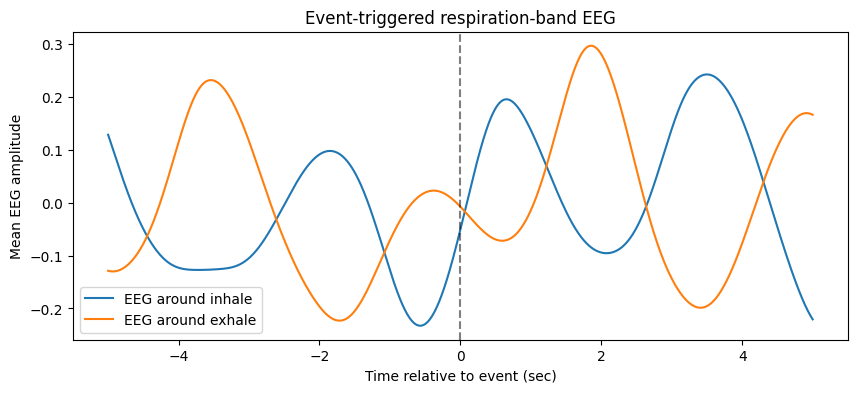

In [178]:
# --------------------------------------------------
# Event-triggered EEG averages
# --------------------------------------------------

window_sec = 5
window_samp = int(window_sec * fs_eeg)

segments_inhale = []
segments_exhale = []

for t in inhale_times:
    center = int(t * fs_eeg)

    start = center - window_samp
    stop = center + window_samp

    if start >= 0 and stop < len(eeg_resp_z):
        segments_inhale.append(eeg_resp_z[start:stop])

for t in exhale_times:
    center = int(t * fs_eeg)

    start = center - window_samp
    stop = center + window_samp

    if start >= 0 and stop < len(eeg_resp_z):
        segments_exhale.append(eeg_resp_z[start:stop])

segments_inhale = np.array(segments_inhale)
segments_exhale = np.array(segments_exhale)

mean_inhale = np.mean(segments_inhale, axis=0)
mean_exhale = np.mean(segments_exhale, axis=0)

t_event = np.linspace(-window_sec, window_sec, len(mean_inhale))

plt.figure(figsize=(10,4))

plt.plot(t_event, mean_inhale, label="EEG around inhale")
plt.plot(t_event, mean_exhale, label="EEG around exhale")

plt.axvline(0, color='k', linestyle='--', alpha=0.5)

plt.xlabel("Time relative to event (sec)")
plt.ylabel("Mean EEG amplitude")
plt.title("Event-triggered respiration-band EEG")

plt.legend()
plt.show()

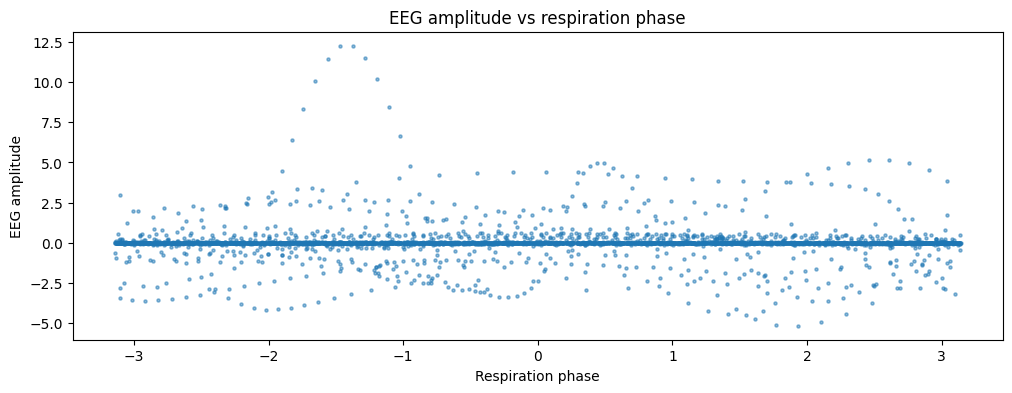

In [179]:
from scipy.signal import hilbert

analytic = hilbert(bi_resp_z)
resp_phase = np.angle(analytic)

plt.figure(figsize=(12,4))

plt.scatter(
    resp_phase,
    eeg_on_bi_time_z,
    s=5,
    alpha=0.5
)

plt.xlabel("Respiration phase")
plt.ylabel("EEG amplitude")
plt.title("EEG amplitude vs respiration phase")

plt.show()

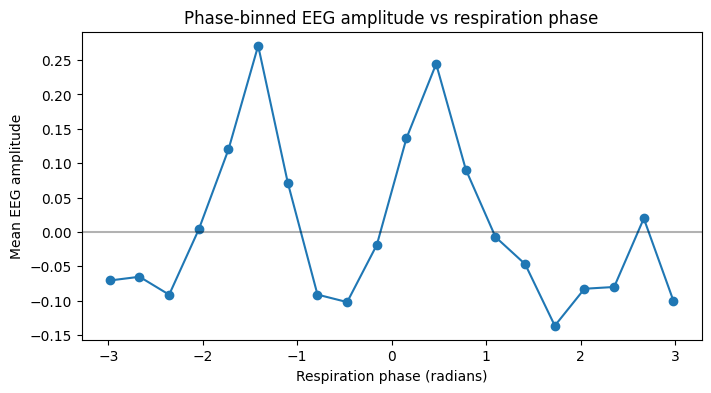

In [180]:
# --------------------------------------------------
# Mean EEG amplitude by respiration phase
# --------------------------------------------------

n_bins = 20

phase_bins = np.linspace(-np.pi, np.pi, n_bins + 1)

bin_centers = (
    phase_bins[:-1] + phase_bins[1:]
) / 2

mean_amp = []

for i in range(n_bins):

    mask = (
        (resp_phase >= phase_bins[i]) &
        (resp_phase < phase_bins[i + 1])
    )

    mean_amp.append(
        np.mean(eeg_on_bi_time_z[mask])
    )

mean_amp = np.array(mean_amp)

plt.figure(figsize=(8,4))

plt.plot(
    bin_centers,
    mean_amp,
    marker='o'
)

plt.xlabel("Respiration phase (radians)")
plt.ylabel("Mean EEG amplitude")

plt.title("Phase-binned EEG amplitude vs respiration phase")

plt.axhline(0, color='k', alpha=0.3)

plt.show()

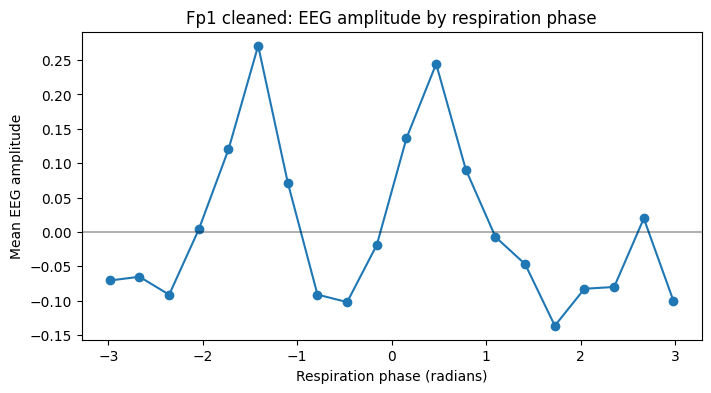

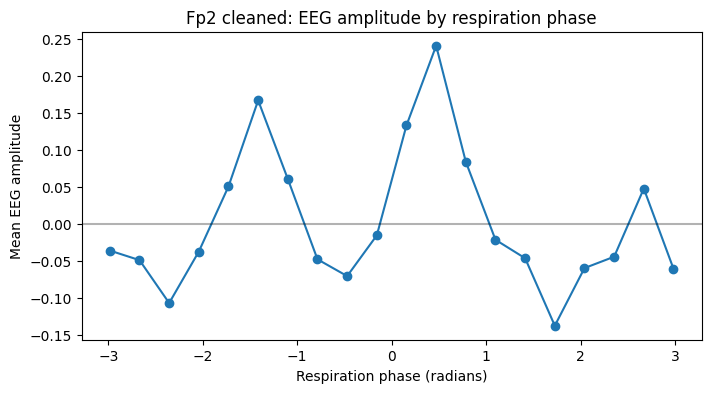

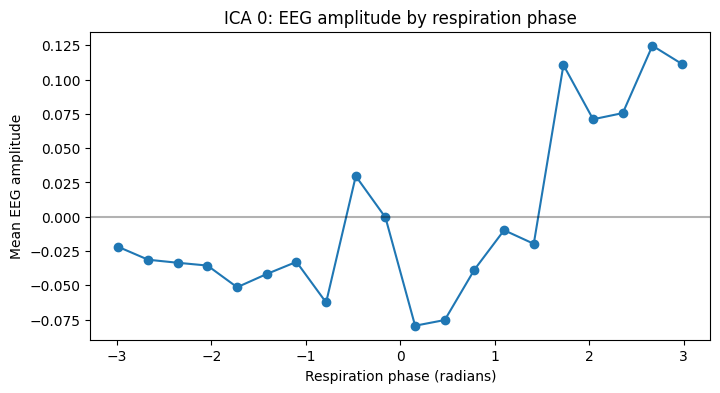

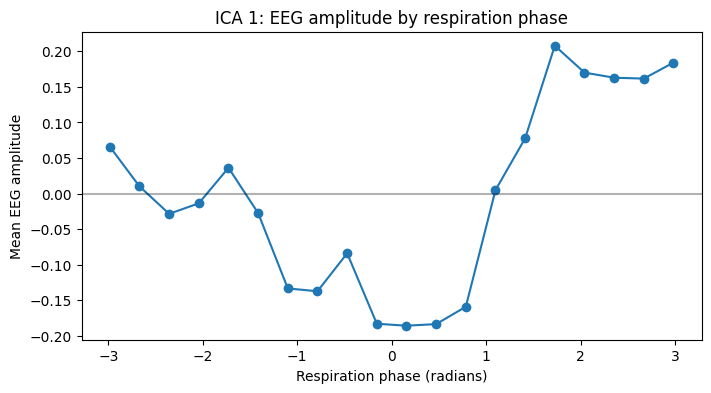

,signal,corr_with_BI,p_value,peak_freq_Hz,peak_breaths_per_min,phase_modulation_strength
0,Fp1 cleaned,0.054606,8.795239e-04,0.100000,6.0,0.407478
1,Fp2 cleaned,0.049504,2.567247e-03,0.100000,6.0,0.378972
2,ICA 0,-0.055088,7.909996e-04,0.100000,6.0,0.204207
3,ICA 1,-0.121050,1.405085e-13,0.133333,8.0,0.393449


In [181]:
# --------------------------------------------------
# Test respiration-phase EEG coupling across signals
# Fp1, Fp2, ICA 0, ICA 1
# --------------------------------------------------

from scipy.signal import hilbert, welch
from scipy.stats import pearsonr
import numpy as np
import matplotlib.pyplot as plt

fs_eeg = 250
fs_resp = 10

# Respiration phase from BI-derived respiration proxy
bi_resp_z = (bi_resp - np.mean(bi_resp)) / np.std(bi_resp)
resp_phase = np.angle(hilbert(bi_resp_z))

# Signals to test
signals_to_test = {
    "Fp1 cleaned": eeg_clean[0],
    "Fp2 cleaned": eeg_clean[1],
    "ICA 0": sources[0],
    "ICA 1": sources[1],
}

n_bins = 20
phase_bins = np.linspace(-np.pi, np.pi, n_bins + 1)
bin_centers = (phase_bins[:-1] + phase_bins[1:]) / 2

results = []

for name, eeg_signal in signals_to_test.items():

    # EEG respiration-band signal
    eeg_resp = bandpass(
        eeg_signal,
        fs=fs_eeg,
        low=0.08,
        high=0.5
    )

    eeg_resp_z = (eeg_resp - np.mean(eeg_resp)) / np.std(eeg_resp)

    eeg_time = np.arange(len(eeg_resp_z)) / fs_eeg

    # Put EEG onto BI respiration time axis
    eeg_on_bi_time = np.interp(
        t_resp,
        eeg_time,
        eeg_resp_z
    )

    eeg_on_bi_time_z = (
        eeg_on_bi_time - np.mean(eeg_on_bi_time)
    ) / np.std(eeg_on_bi_time)

    # Correlation with BI respiration waveform
    r, p = pearsonr(bi_resp_z, eeg_on_bi_time_z)

    # PSD peak in respiration range
    f, pxx = welch(
        eeg_resp_z,
        fs=fs_eeg,
        nperseg=fs_eeg * 30
    )

    mask = (f >= 0.05) & (f <= 0.5)
    peak_freq = f[mask][np.argmax(pxx[mask])]
    peak_bpm = peak_freq * 60

    # Phase-binned amplitude
    mean_amp = []

    for i in range(n_bins):
        phase_mask = (
            (resp_phase >= phase_bins[i]) &
            (resp_phase < phase_bins[i + 1])
        )

        mean_amp.append(
            np.mean(eeg_on_bi_time_z[phase_mask])
        )

    mean_amp = np.array(mean_amp)

    modulation_strength = np.max(mean_amp) - np.min(mean_amp)

    results.append({
        "signal": name,
        "corr_with_BI": r,
        "p_value": p,
        "peak_freq_Hz": peak_freq,
        "peak_breaths_per_min": peak_bpm,
        "phase_modulation_strength": modulation_strength
    })

    # Plot phase-binned coupling curve
    plt.figure(figsize=(8,4))
    plt.plot(bin_centers, mean_amp, marker="o")
    plt.axhline(0, color="k", alpha=0.3)
    plt.xlabel("Respiration phase (radians)")
    plt.ylabel("Mean EEG amplitude")
    plt.title(f"{name}: EEG amplitude by respiration phase")
    plt.show()

# Show summary table
results_df = pd.DataFrame(results)
display(results_df)

In [182]:
resp_component = sources[1]